# 03. 커뮤니티 여론 감성분석
**데이터**: DC인사이드 블루아카이브 마이너 갤러리 게시글
**목표**: 시간에 따른 여론 흐름을 감성 점수로 정량화
**방법**: KNU 감성사전 기반 룰베이스 분석

## 1. 방법론 비교 및 선택 근거

한국어 감성분석에는 여러 방법이 있습니다. 아래 표를 보고 이 프로젝트에 맞는 방법을 선택했습니다.

| 방법 | 설명 | Windows 설치 | 한국어 적합성 | 선택 |
|------|------|-------------|--------------|------|
| **TextBlob** | 영어 전용 사전 기반 | 쉬움 | ❌ 한국어 미지원 | ✗ |
| **KoNLPy + 감성사전** | 형태소 분석 후 사전 매칭 | ⚠️ Java JDK 필요, 설치 복잡 | ✅ 정확함 | 추후 업그레이드용 |
| **Transformers (KoBERT/KoELECTRA)** | 딥러닝 사전학습 모델 | ⚠️ PyTorch(~2GB) 필요 | ✅✅ 매우 정확 | 추후 업그레이드용 |
| **KNU 감성사전 (단어 매칭)** | 14,854개 단어 극성 사전 | ✅ pip 불필요, 다운로드만 | ✅ 한국어 전용 | **✅ 이번에 선택** |

### 선택 이유
- KoNLPy는 Java Development Kit(JDK) 설치가 필요하고, Windows에서 경로 설정이 까다로워 초보자에게 권장하지 않습니다.
- Transformers/PyTorch는 모델 파일이 수백 MB~수 GB로 커서 첫 프로젝트에 부담됩니다.
- **KNU 감성사전**은 부산대학교 인공지능연구실에서 공개한 한국어 감성 어휘 사전으로,
  설치 없이 GitHub에서 JSON으로 받아 바로 쓸 수 있습니다.

> 📌 향후 더 높은 정확도가 필요하면 `transformers` 라이브러리의 `hun3359/klue-bert-base-sentiment` 모델로 교체할 수 있습니다.

## 2. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import json
import re
from pathlib import Path
from collections import Counter

# ── 한글 폰트 설정 (Windows 기본 폰트) ────────────────────
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 120

ROOT = Path().resolve().parent   # notebooks/ → bluearc/
RAW  = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(exist_ok=True)

print("설정 완료")
print(f"프로젝트 루트: {ROOT}")

설정 완료
프로젝트 루트: C:\Dev\bluearc


## 3. 데이터 로드 및 기본 탐색 (EDA)

In [2]:
df = pd.read_csv(RAW / "dcinside_bluearchive_raw.csv")
print(f"행 × 열: {df.shape}")
print(f"컬럼: {list(df.columns)}")
df.head(10)

행 × 열: (148, 9)
컬럼: ['post_no', 'title', 'post_url', 'nickname', 'date_full', 'date_short', 'view_count', 'recommend', 'comment_count']


,post_no,title,post_url,nickname,date_full,date_short,view_count,recommend,comment_count
0,23302,"허,,,참,,,내,,,, 제 성검이 빛나오릅니다요,,, ㅋ ㅋ",https://gall.dcinside.com/mgallery/board/view/...,검은군주,2026-06-21 21:42:46,6.21,50,0,6.0
1,23301,어흐,https://gall.dcinside.com/mgallery/board/view/...,검은군주,2026-06-21 18:11:03,6.21,41,0,2.0
2,23300,맞다 나도 뒤늦게 피크닉 인증~~,https://gall.dcinside.com/mgallery/board/view/...,김취,2026-06-21 00:15:31,6.21,64,0,7.0
3,23299,급속노화.gif,https://gall.dcinside.com/mgallery/board/view/...,유티,2026-06-20 23:32:10,6.20,57,0,3.0
4,23298,수키키 선물 멀지는 모르겠는데,https://gall.dcinside.com/mgallery/board/view/...,검은군주,2026-06-20 23:09:54,6.20,48,0,8.0
5,23297,오늘 라인업만 봐도 가히 페스급인데,https://gall.dcinside.com/mgallery/board/view/...,김취,2026-06-20 22:28:38,6.20,49,0,8.0
6,23296,중국몽.. 함께하시겠습니까?,https://gall.dcinside.com/mgallery/board/view/...,검은군주,2026-06-20 22:01:18,6.20,45,0,7.0
7,23295,도파민 롤러코스터네 ㅅㅂ,https://gall.dcinside.com/mgallery/board/view/...,Nurserymaid,2026-06-20 21:59:01,6.20,28,0,NaN
8,23294,인질 대폭발 ㅅㅂ ㅋㅋㅋㅋ,https://gall.dcinside.com/mgallery/board/view/...,유티,2026-06-20 21:01:58,6.20,37,0,3.0
9,23293,앞으로 제 최애 학원은 산해경입니다,https://gall.dcinside.com/mgallery/board/view/...,검은군주,2026-06-20 20:10:15,6.20,41,0,6.0


In [3]:
# 날짜 파싱 (date_full: "2025-01-01 12:00:00" 형식)
df['date'] = pd.to_datetime(df['date_full'], errors='coerce')
df['date_only'] = df['date'].dt.date
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.day_name()

# 수치 컬럼 결측값 0 채우기 (댓글 없는 게시글)
for col in ['view_count', 'recommend', 'comment_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print("날짜 범위:", df['date'].min(), "~", df['date'].max())
print("결측값:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.describe()

날짜 범위: 2026-05-18 11:20:41 ~ 2026-06-21 21:42:46
결측값:
Series([], dtype: int64)


,post_no,date_short,view_count,recommend,comment_count,date,hour
count,148.000000,148.000000,148.000000,148.000000,148.000000,148,148.000000
mean,23225.702703,5.853243,66.871622,0.020270,4.141892,2026-06-07 09:52:56.533783,14.945946
min,23149.000000,5.180000,28.000000,0.000000,0.000000,2026-05-18 11:20:41,0.000000
25%,23187.750000,5.280000,55.750000,0.000000,2.000000,2026-05-28 16:48:03.250000,12.000000
50%,23225.500000,6.090000,66.000000,0.000000,4.000000,2026-06-09 18:36:39,16.000000
75%,23263.250000,6.142500,77.000000,0.000000,5.000000,2026-06-14 23:38:37.250000,20.000000
max,23302.000000,6.210000,113.000000,1.000000,49.000000,2026-06-21 21:42:46,23.000000
std,44.438517,0.411802,16.741037,0.141402,4.552057,NaN,6.028034


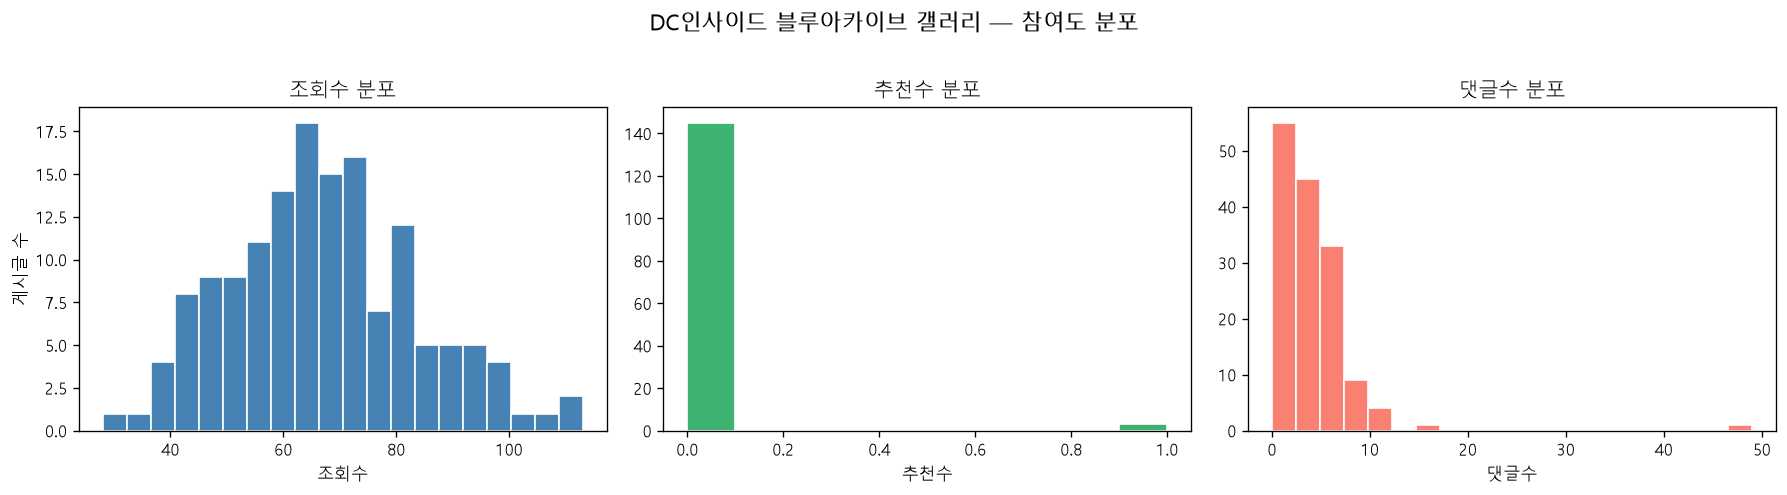

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 조회수 분포
axes[0].hist(df['view_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('조회수 분포')
axes[0].set_xlabel('조회수')
axes[0].set_ylabel('게시글 수')

# 추천수 분포
axes[1].hist(df['recommend'], bins=10, color='mediumseagreen', edgecolor='white')
axes[1].set_title('추천수 분포')
axes[1].set_xlabel('추천수')

# 댓글수 분포
axes[2].hist(df['comment_count'], bins=20, color='salmon', edgecolor='white')
axes[2].set_title('댓글수 분포')
axes[2].set_xlabel('댓글수')

fig.suptitle('DC인사이드 블루아카이브 갤러리 — 참여도 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_engagement_dist.png", bbox_inches='tight')
plt.show()

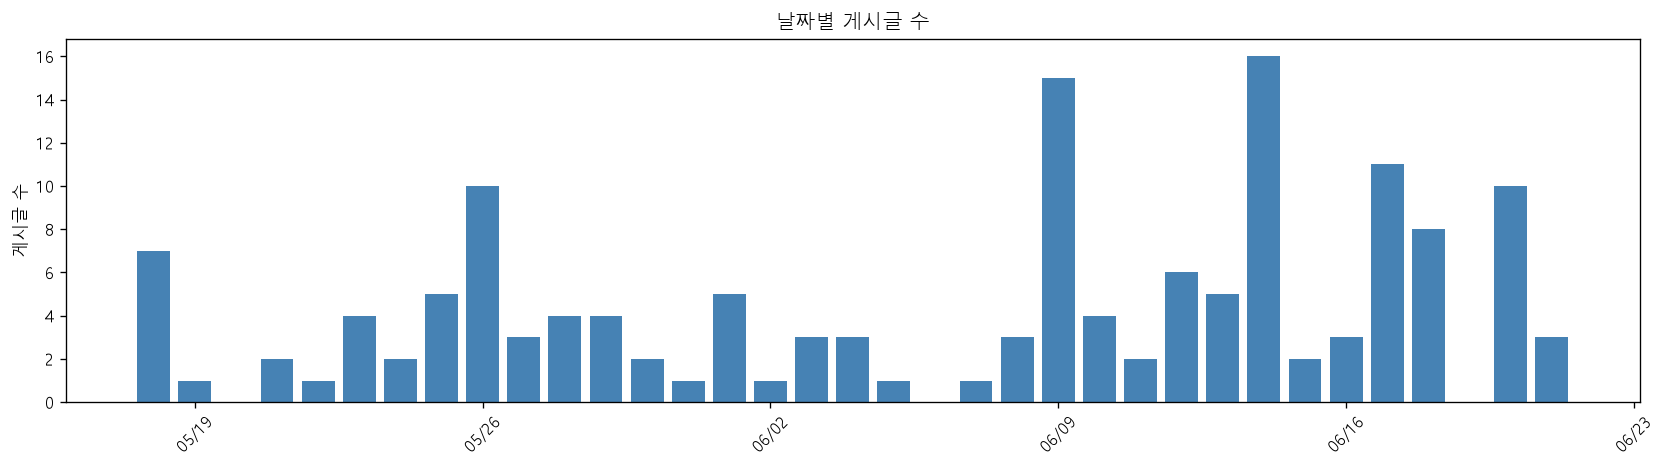

In [5]:
# 날짜별 게시글 수
daily = df.groupby('date_only').size().reset_index(name='post_count')
daily['date_only'] = pd.to_datetime(daily['date_only'])

plt.figure(figsize=(14, 4))
plt.bar(daily['date_only'], daily['post_count'], color='steelblue', width=0.8)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
plt.title('날짜별 게시글 수')
plt.ylabel('게시글 수')
plt.tight_layout()
plt.savefig(ROOT / "reports" / "eda_daily_posts.png", bbox_inches='tight')
plt.show()

## 4. KNU 한국어 감성사전 준비

[KNU 감성사전](https://github.com/park1200656/KnuSentiLex)은 부산대학교 인공지능연구실이 공개한
한국어 감성 어휘 사전입니다. 14,854개 단어에 극성(긍정/부정/중립) 정보가 포함되어 있습니다.

- `polarity: "1"` → 긍정 단어
- `polarity: "-1"` → 부정 단어
- `polarity: "0"` → 중립 단어

In [6]:
SENTI_URL  = "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/data/SentiWord_info.json"
SENTI_CACHE = ROOT / "data" / "raw" / "knu_sentilex.json"

def load_sentilex():
    """KNU 감성사전 로드. 로컬 캐시 우선, 없으면 GitHub에서 다운로드."""
    if SENTI_CACHE.exists():
        print(f"캐시에서 로드: {SENTI_CACHE}")
        with open(SENTI_CACHE, encoding='utf-8') as f:
            data = json.load(f)
    else:
        print(f"GitHub에서 다운로드 중...")
        resp = requests.get(SENTI_URL, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        with open(SENTI_CACHE, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False)
        print(f"캐시 저장 완료: {SENTI_CACHE}")

    # {단어: 극성(int)} 딕셔너리로 변환
    lexicon = {}
    for item in data:
        word = item.get('word', '').strip()
        try:
            polarity = int(item.get('polarity', 0))
        except (ValueError, TypeError):
            polarity = 0
        if word:
            lexicon[word] = polarity
    return lexicon

lexicon = load_sentilex()
print(f"\n총 단어 수: {len(lexicon):,}")
print(f"긍정 단어: {sum(1 for v in lexicon.values() if v > 0):,}")
print(f"부정 단어: {sum(1 for v in lexicon.values() if v < 0):,}")
print(f"중립 단어: {sum(1 for v in lexicon.values() if v == 0):,}")

# 예시 확인
samples = {w: v for w, v in list(lexicon.items()) if v != 0 and len(w) > 1 and w.isalpha()}
pos_ex = [w for w, v in samples.items() if v > 0][:5]
neg_ex = [w for w, v in samples.items() if v < 0][:5]
print(f"\n긍정 단어 예시: {pos_ex}")
print(f"부정 단어 예시: {neg_ex}")

GitHub에서 다운로드 중...


캐시 저장 완료: C:\Dev\bluearc\data\raw\knu_sentilex.json

총 단어 수: 14,852
긍정 단어: 4,871
부정 단어: 9,827
중립 단어: 154

긍정 단어 예시: ['XD', 'ㄱㅅ', 'ㄱㅇㄷ', '가까이하다', '가능하다']
부정 단어 예시: ['가꾸러뜨리다', '가꾸러트리다', '가난', '가난뱅이', '가난살이']


## 5. 감성 점수 계산

In [7]:
def clean_text(text: str) -> str:
    """특수문자·이모티콘 제거, 소문자 변환."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', text)   # 한글·영숫자·공백만 유지
    return text.strip()

def score_text(text: str, lexicon: dict) -> dict:
    """
    텍스트를 공백 기준으로 토크나이징한 뒤 KNU 감성사전과 매칭.
    단어별 극성 합산 → 긍정/부정/중립 판정.

    반환: {'score': int, 'label': str, 'matched_pos': list, 'matched_neg': list}
    """
    cleaned = clean_text(text)
    tokens  = cleaned.split()

    pos_words, neg_words = [], []
    total_score = 0

    for token in tokens:
        # 원형 그대로 매칭
        if token in lexicon:
            pol = lexicon[token]
            if pol > 0:
                pos_words.append(token)
            elif pol < 0:
                neg_words.append(token)
            total_score += pol

    if total_score > 0:
        label = '긍정'
    elif total_score < 0:
        label = '부정'
    else:
        label = '중립'

    return {
        'score':       total_score,
        'label':       label,
        'matched_pos': pos_words,
        'matched_neg': neg_words,
        'matched_n':   len(pos_words) + len(neg_words),
    }

# 테스트
tests = [
    "정말 좋아 최고야 행복해",
    "너무 화나고 짜증나 최악이다",
    "오늘 업데이트 했어",
]
for t in tests:
    r = score_text(t, lexicon)
    print(f"[{r['label']:2}|{r['score']:+d}] '{t}'")
    print(f"       긍정어: {r['matched_pos']}  부정어: {r['matched_neg']}")
    print()

[긍정|+2] '정말 좋아 최고야 행복해'
       긍정어: ['좋아']  부정어: []

[부정|-2] '너무 화나고 짜증나 최악이다'
       긍정어: []  부정어: ['화나고']

[중립|+0] '오늘 업데이트 했어'
       긍정어: []  부정어: []



## 6. 전체 데이터에 감성 분석 적용

In [8]:
results = df['title'].apply(lambda t: score_text(t, lexicon))

df['senti_score'] = results.apply(lambda r: r['score'])
df['senti_label'] = results.apply(lambda r: r['label'])
df['matched_pos']  = results.apply(lambda r: r['matched_pos'])
df['matched_neg']  = results.apply(lambda r: r['matched_neg'])
df['matched_n']    = results.apply(lambda r: r['matched_n'])

print("감성 라벨 분포:")
print(df['senti_label'].value_counts())
print(f"\n사전 매칭 없는 게시글 비율: {(df['matched_n'] == 0).mean():.1%}")
print("→ 매칭이 없는 경우 모두 '중립'으로 분류됩니다.")

# 전처리 결과 저장
df.to_csv(PROCESSED / "posts_with_sentiment.csv", index=False, encoding='utf-8-sig')
print(f"\n저장: {PROCESSED / 'posts_with_sentiment.csv'}")
df[['post_no','title','date_short','senti_label','senti_score','matched_pos','matched_neg']].head(10)

감성 라벨 분포:
senti_label
중립    142
긍정      5
부정      1
Name: count, dtype: int64

사전 매칭 없는 게시글 비율: 95.9%
→ 매칭이 없는 경우 모두 '중립'으로 분류됩니다.

저장: C:\Dev\bluearc\data\processed\posts_with_sentiment.csv


,post_no,title,date_short,senti_label,senti_score,matched_pos,matched_neg
0,23302,"허,,,참,,,내,,,, 제 성검이 빛나오릅니다요,,, ㅋ ㅋ",6.21,중립,0,[],[]
1,23301,어흐,6.21,중립,0,[],[]
2,23300,맞다 나도 뒤늦게 피크닉 인증~~,6.21,중립,0,[],[]
3,23299,급속노화.gif,6.20,중립,0,[],[]
4,23298,수키키 선물 멀지는 모르겠는데,6.20,중립,0,[],[]
5,23297,오늘 라인업만 봐도 가히 페스급인데,6.20,중립,0,[],[]
6,23296,중국몽.. 함께하시겠습니까?,6.20,중립,0,[],[]
7,23295,도파민 롤러코스터네 ㅅㅂ,6.20,중립,0,[],[]
8,23294,인질 대폭발 ㅅㅂ ㅋㅋㅋㅋ,6.20,중립,0,[],[]
9,23293,앞으로 제 최애 학원은 산해경입니다,6.20,중립,0,[],[]


## 7. 감성 분포 시각화

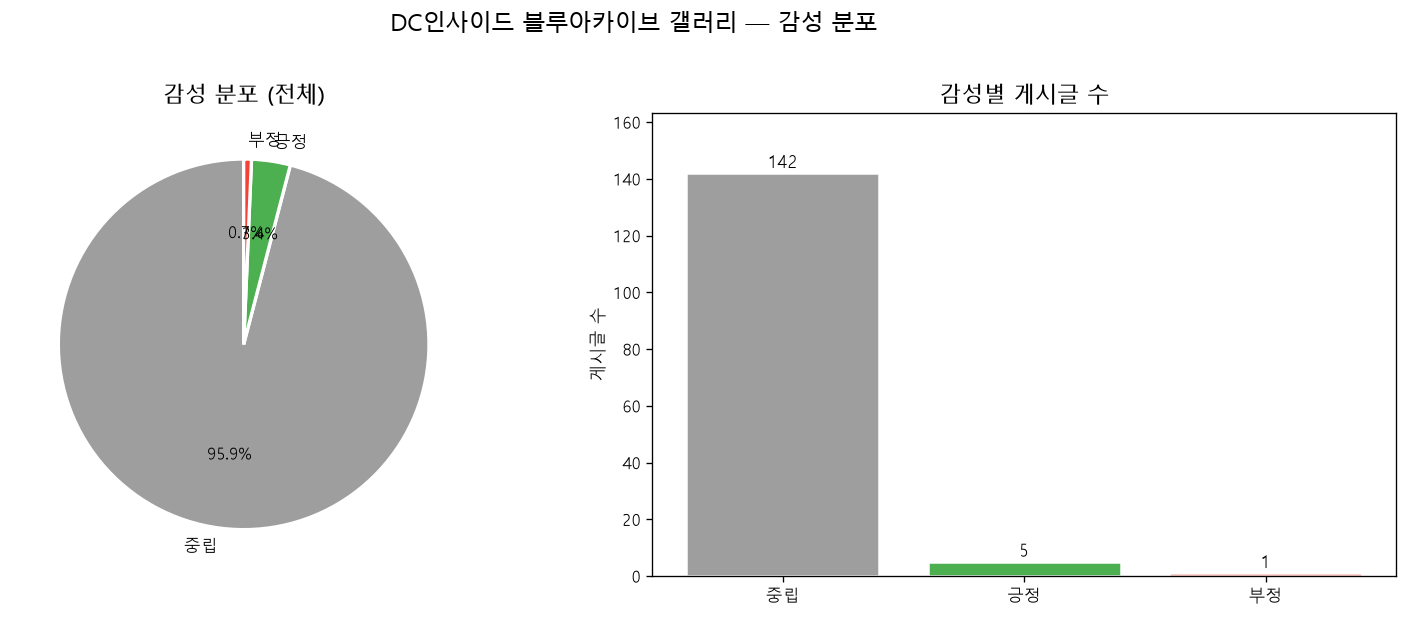

In [9]:
label_counts = df['senti_label'].value_counts()
colors = {'긍정': '#4CAF50', '중립': '#9E9E9E', '부정': '#F44336'}
color_list = [colors[l] for l in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 파이 차트
axes[0].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=color_list,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('감성 분포 (전체)', fontsize=13)

# 막대 그래프
bars = axes[1].bar(label_counts.index, label_counts.values, color=color_list, edgecolor='white', linewidth=1.5)
axes[1].set_title('감성별 게시글 수', fontsize=13)
axes[1].set_ylabel('게시글 수')
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11)
axes[1].set_ylim(0, label_counts.max() * 1.15)

fig.suptitle('DC인사이드 블루아카이브 갤러리 — 감성 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "sentiment_distribution.png", bbox_inches='tight')
plt.show()

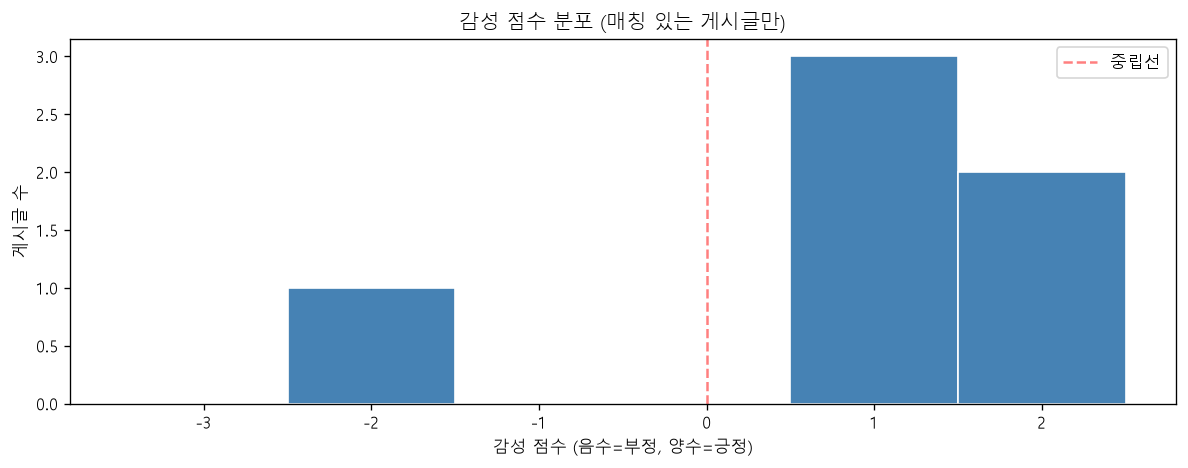

분석 대상: 6건 / 전체 148건


In [10]:
# 감성 점수 분포 (히스토그램)
fig, ax = plt.subplots(figsize=(10, 4))
nonzero = df[df['senti_score'] != 0]['senti_score']
ax.hist(nonzero, bins=range(int(nonzero.min())-1, int(nonzero.max())+2),
        color='steelblue', edgecolor='white', align='left')
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='중립선')
ax.set_title('감성 점수 분포 (매칭 있는 게시글만)')
ax.set_xlabel('감성 점수 (음수=부정, 양수=긍정)')
ax.set_ylabel('게시글 수')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "sentiment_score_dist.png", bbox_inches='tight')
plt.show()
print(f"분석 대상: {len(nonzero)}건 / 전체 {len(df)}건")

## 8. 시간에 따른 여론 변화

날짜별 평균 감성 점수를 계산하고, 이동평균으로 추세를 부드럽게 표현합니다.
수집 기간이 짧을 경우 추세보다 **노이즈**가 클 수 있습니다 — 수집량을 늘리면 더 의미 있어집니다.

In [11]:
daily_senti = (
    df.groupby('date_only')
    .agg(
        avg_score=('senti_score', 'mean'),
        post_count=('post_no', 'count'),
        pos_ratio=('senti_label', lambda x: (x == '긍정').mean()),
        neg_ratio=('senti_label', lambda x: (x == '부정').mean()),
    )
    .reset_index()
)
daily_senti['date_only'] = pd.to_datetime(daily_senti['date_only'])

# 3일 이동평균
daily_senti['score_ma3'] = daily_senti['avg_score'].rolling(3, min_periods=1).mean()

daily_senti.tail()

,date_only,avg_score,post_count,pos_ratio,neg_ratio,score_ma3
27,2026-06-16,0.0,3,0.0,0.0,0.0625
28,2026-06-17,0.0,11,0.0,0.0,0.0000
29,2026-06-18,0.0,8,0.0,0.0,0.0000
30,2026-06-20,0.0,10,0.0,0.0,0.0000
31,2026-06-21,0.0,3,0.0,0.0,0.0000


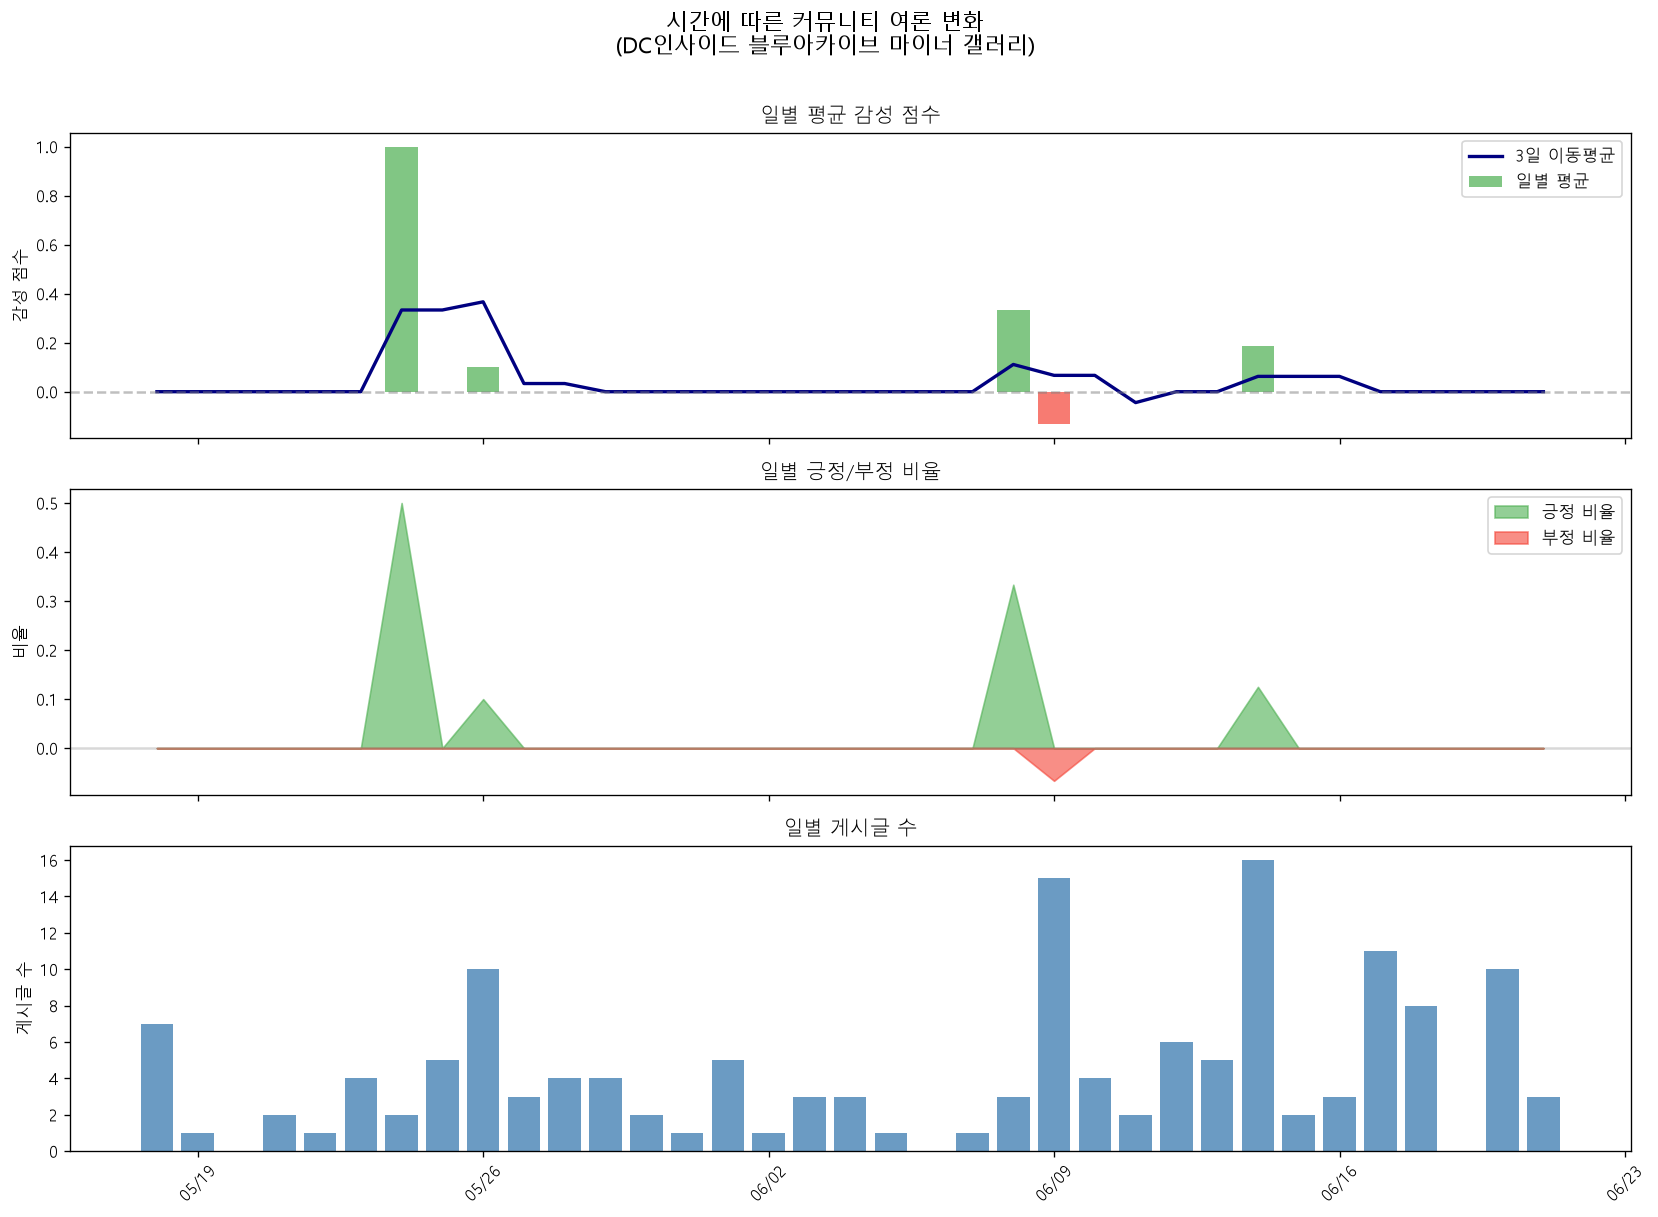

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ① 일별 평균 감성 점수
axes[0].bar(daily_senti['date_only'], daily_senti['avg_score'],
            color=['#4CAF50' if v >= 0 else '#F44336' for v in daily_senti['avg_score']],
            alpha=0.7, label='일별 평균')
axes[0].plot(daily_senti['date_only'], daily_senti['score_ma3'],
             color='navy', linewidth=2, label='3일 이동평균')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('일별 평균 감성 점수')
axes[0].set_ylabel('감성 점수')
axes[0].legend()

# ② 긍정/부정 비율 스택 영역 차트
axes[1].fill_between(daily_senti['date_only'], daily_senti['pos_ratio'],
                     alpha=0.6, color='#4CAF50', label='긍정 비율')
axes[1].fill_between(daily_senti['date_only'], -daily_senti['neg_ratio'],
                     alpha=0.6, color='#F44336', label='부정 비율')
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_title('일별 긍정/부정 비율')
axes[1].set_ylabel('비율')
axes[1].legend()

# ③ 일별 게시글 수
axes[2].bar(daily_senti['date_only'], daily_senti['post_count'],
            color='steelblue', alpha=0.8)
axes[2].set_title('일별 게시글 수')
axes[2].set_ylabel('게시글 수')

# x축 포맷
for ax in axes:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle('시간에 따른 커뮤니티 여론 변화\n(DC인사이드 블루아카이브 마이너 갤러리)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "sentiment_timeline.png", bbox_inches='tight')
plt.show()

## 9. 감성과 참여도(조회수·댓글수)의 관계

C:\Users\Mingyun\AppData\Local\Temp\ipykernel_49108\1387092501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='senti_label', y='view_count',
C:\Users\Mingyun\AppData\Local\Temp\ipykernel_49108\1387092501.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='senti_label', y='comment_count',


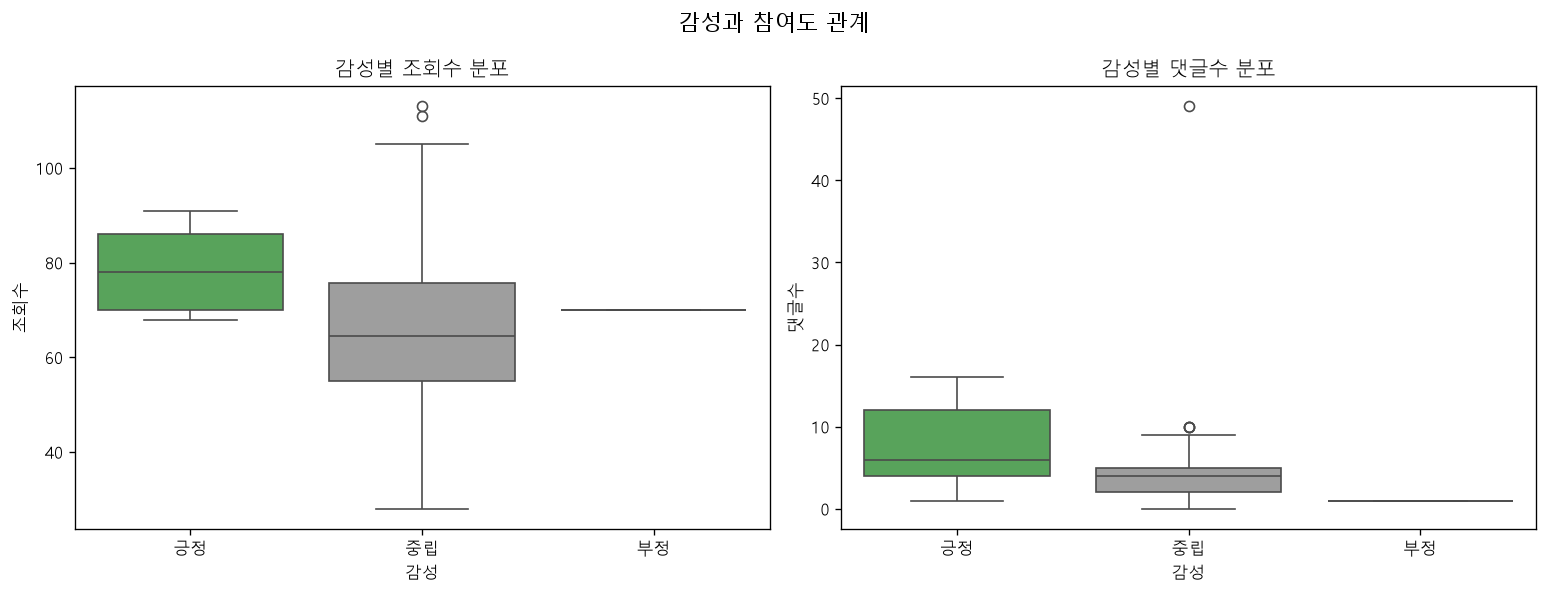

             view_count  comment_count
senti_label                           
긍정                 78.6            7.8
부정                 70.0            1.0
중립                 66.4            4.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'긍정': '#4CAF50', '중립': '#9E9E9E', '부정': '#F44336'}

# 감성별 조회수 박스플롯
sns.boxplot(data=df, x='senti_label', y='view_count',
            palette=palette, order=['긍정', '중립', '부정'], ax=axes[0])
axes[0].set_title('감성별 조회수 분포')
axes[0].set_xlabel('감성')
axes[0].set_ylabel('조회수')

# 감성별 댓글수 박스플롯
sns.boxplot(data=df, x='senti_label', y='comment_count',
            palette=palette, order=['긍정', '중립', '부정'], ax=axes[1])
axes[1].set_title('감성별 댓글수 분포')
axes[1].set_xlabel('감성')
axes[1].set_ylabel('댓글수')

fig.suptitle('감성과 참여도 관계', fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "sentiment_vs_engagement.png", bbox_inches='tight')
plt.show()

# 수치 요약
print(df.groupby('senti_label')[['view_count','comment_count']].mean().round(1))

## 10. 감성별 자주 나오는 키워드

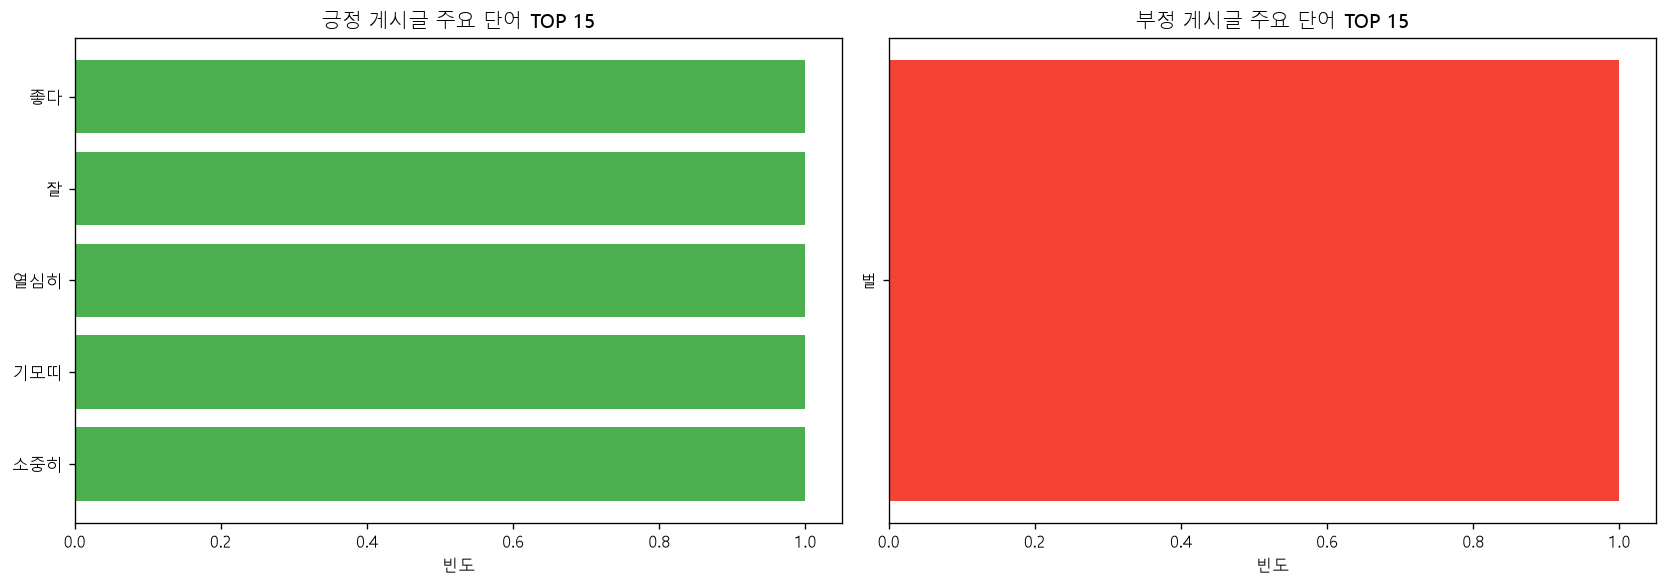

In [14]:
from itertools import chain

pos_words_all = list(chain.from_iterable(df[df['senti_label']=='긍정']['matched_pos']))
neg_words_all = list(chain.from_iterable(df[df['senti_label']=='부정']['matched_neg']))

pos_counter = Counter(pos_words_all).most_common(15)
neg_counter = Counter(neg_words_all).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if pos_counter:
    words, counts = zip(*pos_counter)
    axes[0].barh(words[::-1], counts[::-1], color='#4CAF50')
    axes[0].set_title('긍정 게시글 주요 단어 TOP 15')
    axes[0].set_xlabel('빈도')
else:
    axes[0].text(0.5, 0.5, '매칭 단어 없음', ha='center', transform=axes[0].transAxes)

if neg_counter:
    words, counts = zip(*neg_counter)
    axes[1].barh(words[::-1], counts[::-1], color='#F44336')
    axes[1].set_title('부정 게시글 주요 단어 TOP 15')
    axes[1].set_xlabel('빈도')
else:
    axes[1].text(0.5, 0.5, '매칭 단어 없음', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "sentiment_keywords.png", bbox_inches='tight')
plt.show()

## ⚠️ 11. 방법론 한계 및 주의사항

### 이 분석의 정확도를 제한하는 요인들

#### 1. 커뮤니티 특유의 은어·줄임말
DC인사이드 등 한국 커뮤니티는 사전에 없는 표현이 매우 많습니다.

| 은어/줄임말 | 실제 의미 | 사전 매칭 여부 |
|------------|---------|--------------|
| `ㄹㅇ`, `레알` | 정말로 (강조) | ❌ 미매칭 |
| `ㅈㄴ`, `개-` | 매우, 엄청 (강조) | ❌ 미매칭 |
| `ㄷㄷ`, `덜덜` | 놀라움, 감탄 | ❌ 미매칭 |
| `ㅅㅂ` | 부정적 감탄사 | ❌ 미매칭 |
| `미쳤다` | 긍정적 감탄 ("대박") | 사전상 부정어 → 오분류 |
| `터졌다` | 캐릭터 강함 칭찬 | 사전상 부정어 → 오분류 |

#### 2. 비꼬기(irony)와 역설적 표현
- `"진짜 최고네요~"` (반어법) → 사전에서는 긍정으로 분류되지만 실제 부정
- 블루아카이브 특유의 밈 표현은 감성사전으로 판별 불가

#### 3. 형태소 미분리
이 분석은 공백 기준 토크나이징만 사용합니다.
`"너무좋아"` vs `"너무 좋아"` — 붙여쓰면 매칭 실패.
→ KoNLPy를 도입하면 이 문제를 줄일 수 있습니다.

#### 4. 데이터 규모
현재 148건으로 시계열 추세를 판단하기 어렵습니다.
`collect_community.py`의 `MAX_PAGES`를 50~100으로 늘리면 더 의미 있는 분석이 가능합니다.

#### 5. 제목만 분석
게시글 본문은 수집하지 않아 제목의 짧은 텍스트만 분석합니다.
제목은 보통 1~5개 단어로 구성되어 감성 신호가 약할 수 있습니다.

---

### 권장 개선 방향
1. **단기**: `collect_community.py`에 본문 수집 기능 추가
2. **중기**: `KoNLPy` 설치 (Java JDK 11 → 환경변수 `JAVA_HOME` 설정 후 `pip install konlpy`)
3. **장기**: `transformers` + `hun3359/klue-bert-base-sentiment` 모델로 교체 (pip만으로 설치 가능, 더 높은 정확도)

```python
# 장기 업그레이드 예시 (현재는 실행하지 마세요 — torch 설치 필요)
# from transformers import pipeline
# sentiment = pipeline("text-classification", model="hun3359/klue-bert-base-sentiment")
# result = sentiment("정말 재밌는 업데이트네요")
```

## 12. 분석 결과 요약

In [15]:
print("=" * 55)
print("  감성분석 최종 요약")
print("=" * 55)
print(f"  분석 게시글 수  : {len(df)}건")
print(f"  분석 기간       : {df['date'].min().date()} ~ {df['date'].max().date()}")
print()

dist = df['senti_label'].value_counts()
for label, cnt in dist.items():
    bar = "█" * int(cnt / len(df) * 30)
    print(f"  {label:3} | {bar:30} {cnt:4}건 ({cnt/len(df):.1%})")

print()
print(f"  사전 미매칭 비율: {(df['matched_n']==0).mean():.1%} (중립으로 처리)")
print()
print(f"  저장된 파일:")
print(f"    data/processed/posts_with_sentiment.csv")
print(f"    reports/sentiment_distribution.png")
print(f"    reports/sentiment_timeline.png")
print(f"    reports/sentiment_keywords.png")
print("=" * 55)

  감성분석 최종 요약
  분석 게시글 수  : 148건
  분석 기간       : 2026-05-18 ~ 2026-06-21

  중립  | ████████████████████████████    142건 (95.9%)
  긍정  | █                                 5건 (3.4%)
  부정  |                                   1건 (0.7%)

  사전 미매칭 비율: 95.9% (중립으로 처리)

  저장된 파일:
    data/processed/posts_with_sentiment.csv
    reports/sentiment_distribution.png
    reports/sentiment_timeline.png
    reports/sentiment_keywords.png
